<a href="https://colab.research.google.com/github/kamalrajarulprakasam-sudo/BronzeBadge_GenAIAssignments/blob/main/Problem3_FraudDetection_NeuralNetwork/neural_network_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 3: Neural Network Architecture Visualization
## Credit Card Fraud Detection Network

---
**Course:** L3-L5 Gen AI App Developer | Bronze Badge  
**Topic:** Deep Learning — Neural Network Architecture  

### Problem Statement
Draw and visualize the architecture of a **Neural Network** designed to classify  
**fraudulent vs non-fraudulent credit card transactions**.

### Input Features (6 features)
| # | Feature | Description |
|---|---------|-------------|
| 1 | TransactionAmount | Value of the transaction in ₹ |
| 2 | TransactionTime | Time of transaction (hour 0–23) |
| 3 | MerchantCategory | Category code of merchant (encoded) |
| 4 | CustomerAge | Age of account holder |
| 5 | AccountBalance | Current account balance |
| 6 | NumTransactionsToday | Count of transactions that day |

### Output
**Fraud label:** `0 = Genuine Transaction`, `1 = Fraudulent Transaction`

### Architecture Summary
```
Input Layer  → 6 neurons  (one per feature)
Hidden Layer 1 → 12 neurons (ReLU activation)
Hidden Layer 2 → 8 neurons  (ReLU activation)
Hidden Layer 3 → 4 neurons  (ReLU activation)
Output Layer → 1 neuron   (Sigmoid activation → probability of fraud)
```

In [1]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import numpy as np                    # Numerical operations
import matplotlib.pyplot as plt       # Core plotting library
import matplotlib.patches as mpatches # For custom legend patches
from matplotlib.patches import FancyArrowPatch  # For styled arrows
import warnings
warnings.filterwarnings('ignore')

print('Step 1 COMPLETE: Libraries imported!')

Step 1 COMPLETE: Libraries imported!


In [2]:
# ============================================================
# STEP 2: Define Network Architecture Configuration
# ============================================================
# Each value in the list represents the number of neurons in that layer
# Order: Input → Hidden Layers → Output

# Layer neuron counts
layer_sizes = [6, 12, 8, 4, 1]   # Input(6) → H1(12) → H2(8) → H3(4) → Output(1)

# Layer names for labeling
layer_names = [
    'Input Layer\n(6 neurons)',
    'Hidden Layer 1\n(12 neurons, ReLU)',
    'Hidden Layer 2\n(8 neurons, ReLU)',
    'Hidden Layer 3\n(4 neurons, ReLU)',
    'Output Layer\n(1 neuron, Sigmoid)'
]

# Input feature labels for the 6 input neurons
input_labels = [
    'TransactionAmount',
    'TransactionTime',
    'MerchantCategory',
    'CustomerAge',
    'AccountBalance',
    'NumTransactionsToday'
]

# Color for each layer type
layer_colors = [
    '#3498db',   # Blue  → Input layer
    '#e74c3c',   # Red   → Hidden layer 1
    '#e67e22',   # Orange → Hidden layer 2
    '#9b59b6',   # Purple → Hidden layer 3
    '#27ae60'    # Green → Output layer
]

print('Network Architecture:')
for i, (name, size, color) in enumerate(zip(layer_names, layer_sizes, layer_colors)):
    print(f'  Layer {i}: {size:2d} neurons | {name.split(chr(10))[0]}')
total_params = sum(
    layer_sizes[i] * layer_sizes[i+1] + layer_sizes[i+1]  # Weights + biases
    for i in range(len(layer_sizes)-1)
)
print(f'\nTotal Parameters (weights + biases): {total_params}')

Network Architecture:
  Layer 0:  6 neurons | Input Layer
  Layer 1: 12 neurons | Hidden Layer 1
  Layer 2:  8 neurons | Hidden Layer 2
  Layer 3:  4 neurons | Hidden Layer 3
  Layer 4:  1 neurons | Output Layer

Total Parameters (weights + biases): 229


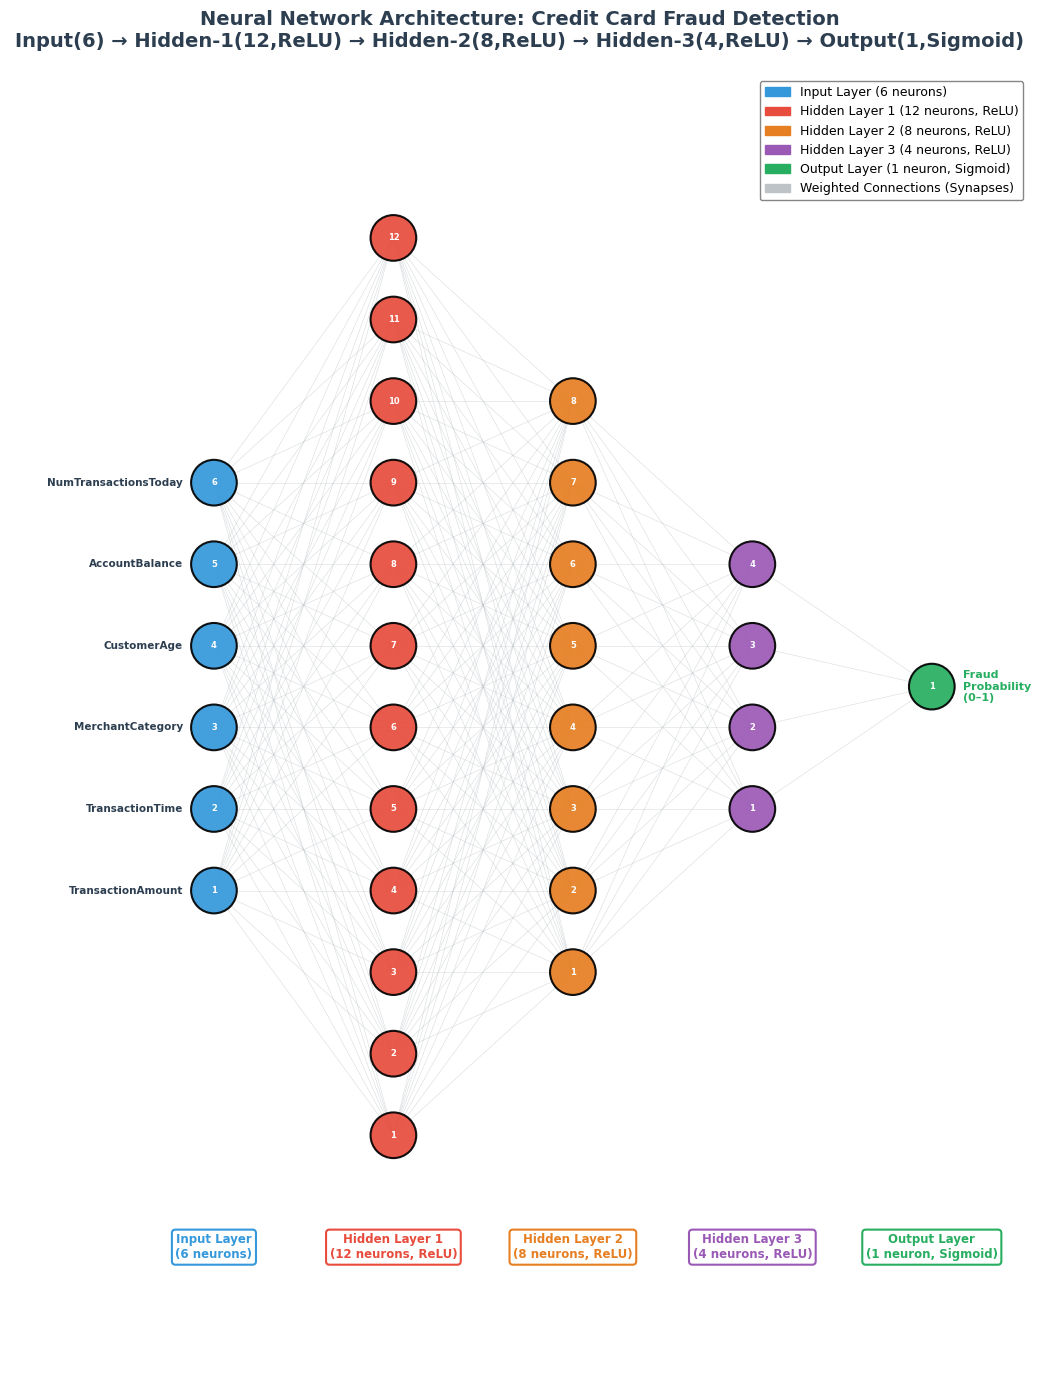

Network architecture diagram saved as: neural_network_architecture.png


In [3]:
# ============================================================
# STEP 3: Draw the Neural Network Architecture
# ============================================================
# Each circle = one neuron
# Lines between circles = connections (weights)
# We draw each layer as a vertical column of circles

def draw_neural_network(ax, layer_sizes, layer_names, layer_colors, input_labels):
    """
    Draw a fully connected neural network diagram.
    ax           : matplotlib Axes object
    layer_sizes  : list of neuron counts per layer
    layer_names  : list of display names per layer
    layer_colors : list of colors per layer
    input_labels : labels for input neurons
    """
    n_layers = len(layer_sizes)          # Total number of layers
    max_neurons = max(layer_sizes)       # Maximum neurons in any single layer (for vertical spacing)

    # Spacing parameters
    h_spacing = 2.2     # Horizontal spacing between layers
    neuron_radius = 0.28  # Radius of each neuron circle
    v_scale = 1.0        # Vertical scale factor

    neuron_positions = []  # Store (x, y) position of every neuron

    # ---- Pass 1: Draw Connections (lines between all neuron pairs in adjacent layers) ----
    for l_idx in range(n_layers - 1):
        n_curr = layer_sizes[l_idx]      # Neurons in current layer
        n_next = layer_sizes[l_idx + 1]  # Neurons in next layer

        # Compute vertical positions for current layer neurons
        y_curr = [(max_neurons - n_curr) / 2 * v_scale + j * v_scale
                  for j in range(n_curr)]
        # Compute vertical positions for next layer neurons
        y_next = [(max_neurons - n_next) / 2 * v_scale + j * v_scale
                  for j in range(n_next)]

        x_curr = l_idx * h_spacing       # X position of current layer
        x_next = (l_idx + 1) * h_spacing # X position of next layer

        for y_c in y_curr:
            for y_n in y_next:
                # Draw a light gray line from (x_curr, y_c) to (x_next, y_n)
                ax.plot([x_curr, x_next], [y_c, y_n],
                        color='#bdc3c7', linewidth=0.4, alpha=0.6, zorder=1)

    # ---- Pass 2: Draw Neurons (filled circles with border) ----
    for l_idx in range(n_layers):
        n_neurons = layer_sizes[l_idx]   # Neurons in this layer
        x_pos = l_idx * h_spacing        # X position for this layer
        color = layer_colors[l_idx]      # Color for this layer

        # Vertical centering: offset so layer is centered vertically
        y_positions = [(max_neurons - n_neurons) / 2 * v_scale + j * v_scale
                       for j in range(n_neurons)]

        layer_pos = []  # Store positions for this layer
        for j, y_pos in enumerate(y_positions):
            # Draw filled circle (neuron)
            circle = plt.Circle(
                (x_pos, y_pos),
                neuron_radius,
                color=color,      # Fill color
                ec='black',       # Edge color
                linewidth=1.5,    # Edge thickness
                zorder=3,         # Draw on top of lines
                alpha=0.92
            )
            ax.add_patch(circle)  # Add circle to axes

            # Label neurons in the input layer with feature names
            if l_idx == 0 and j < len(input_labels):
                ax.text(x_pos - neuron_radius - 0.1, y_pos,
                        input_labels[j],
                        ha='right', va='center', fontsize=7.5,
                        fontweight='bold', color='#2c3e50')

            # Label output neuron
            if l_idx == n_layers - 1:
                ax.text(x_pos + neuron_radius + 0.1, y_pos,
                        'Fraud\nProbability\n(0–1)',
                        ha='left', va='center', fontsize=8,
                        fontweight='bold', color='#27ae60')

            # Add neuron index number inside circle
            ax.text(x_pos, y_pos, str(j+1),
                    ha='center', va='center',
                    fontsize=6, color='white', fontweight='bold', zorder=5)

            layer_pos.append((x_pos, y_pos))
        neuron_positions.append(layer_pos)

        # ---- Layer name label (below each layer) ----
        ax.text(x_pos, -1.2, layer_names[l_idx],
                ha='center', va='top', fontsize=8.5,
                fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, linewidth=1.5))

    return neuron_positions

# Create main figure
fig, ax = plt.subplots(figsize=(22, 14))
ax.set_xlim(-2.5, 10)   # X range
ax.set_ylim(-3.0, 13)   # Y range
ax.set_aspect('equal')  # Equal aspect ratio keeps circles round
ax.axis('off')           # Hide axes

# Draw the network
positions = draw_neural_network(ax, layer_sizes, layer_names, layer_colors, input_labels)

# Title and description
ax.set_title(
    'Neural Network Architecture: Credit Card Fraud Detection\n'
    'Input(6) → Hidden-1(12,ReLU) → Hidden-2(8,ReLU) → Hidden-3(4,ReLU) → Output(1,Sigmoid)',
    fontsize=14, fontweight='bold', pad=20, color='#2c3e50'
)

# Legend patches
legend_items = [
    mpatches.Patch(color='#3498db', label='Input Layer (6 neurons)'),
    mpatches.Patch(color='#e74c3c', label='Hidden Layer 1 (12 neurons, ReLU)'),
    mpatches.Patch(color='#e67e22', label='Hidden Layer 2 (8 neurons, ReLU)'),
    mpatches.Patch(color='#9b59b6', label='Hidden Layer 3 (4 neurons, ReLU)'),
    mpatches.Patch(color='#27ae60', label='Output Layer (1 neuron, Sigmoid)'),
    mpatches.Patch(color='#bdc3c7', label='Weighted Connections (Synapses)')
]
ax.legend(handles=legend_items, loc='upper right', fontsize=9,
          framealpha=0.95, edgecolor='gray', fancybox=True)

plt.tight_layout()
plt.savefig('neural_network_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Network architecture diagram saved as: neural_network_architecture.png')

In [4]:
# ============================================================
# STEP 4: Network Parameter Summary Table
# ============================================================
# For each connection between layers: parameters = (neurons_in × neurons_out) + neurons_out
# Weights: each connection is one weight (W_ij)
# Biases:  each neuron in the next layer has one bias term

print('=== NEURAL NETWORK PARAMETER SUMMARY ===')
print(f'{"Layer Connection":<35} {"Weights":>10} {"Biases":>8} {"Total":>8}')
print('-'*65)

total_weights = 0
total_biases  = 0

layer_labels = ['Input', 'Hidden-1', 'Hidden-2', 'Hidden-3', 'Output']

for i in range(len(layer_sizes) - 1):
    n_in   = layer_sizes[i]       # Neurons in sending layer
    n_out  = layer_sizes[i+1]     # Neurons in receiving layer
    n_w    = n_in * n_out          # Number of weights = full connection
    n_b    = n_out                  # Number of biases = one per output neuron
    n_total = n_w + n_b             # Total parameters in this connection

    total_weights += n_w
    total_biases  += n_b

    label = f'{layer_labels[i]}({n_in}) → {layer_labels[i+1]}({n_out})'
    print(f'{label:<35} {n_w:>10} {n_b:>8} {n_total:>8}')

print('-'*65)
print(f'{"TOTAL":<35} {total_weights:>10} {total_biases:>8} {total_weights+total_biases:>8}')

print(f'\nTotal Trainable Parameters: {total_weights + total_biases}')
print('Each parameter is updated during backpropagation via gradient descent')

=== NEURAL NETWORK PARAMETER SUMMARY ===
Layer Connection                       Weights   Biases    Total
-----------------------------------------------------------------
Input(6) → Hidden-1(12)                     72       12       84
Hidden-1(12) → Hidden-2(8)                  96        8      104
Hidden-2(8) → Hidden-3(4)                   32        4       36
Hidden-3(4) → Output(1)                      4        1        5
-----------------------------------------------------------------
TOTAL                                      204       25      229

Total Trainable Parameters: 229
Each parameter is updated during backpropagation via gradient descent


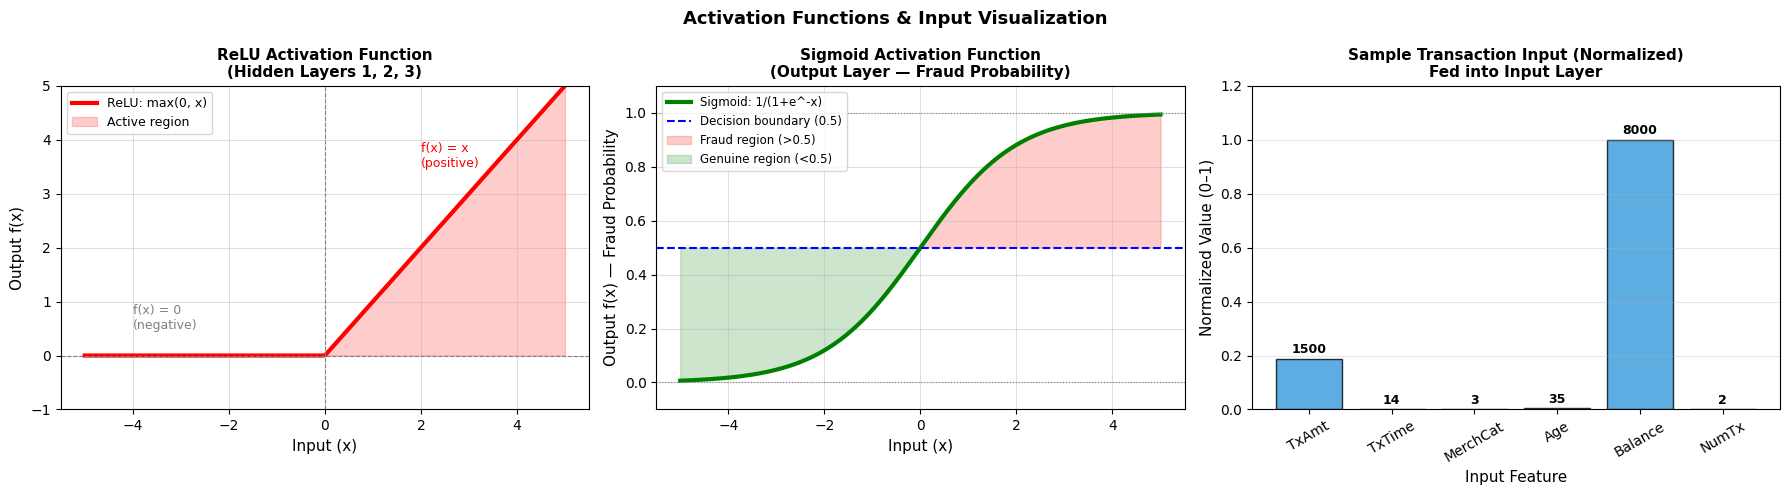

In [5]:
# ============================================================
# STEP 5: Visualize Activation Functions Used in the Network
# ============================================================
# ReLU   (Rectified Linear Unit): max(0, x) — used in hidden layers
# Sigmoid: 1/(1+e^-x)           — used in output layer for binary probability

x = np.linspace(-5, 5, 300)   # 300 evenly spaced x values from -5 to 5

# Compute activation function values
relu    = np.maximum(0, x)         # ReLU: zero for negative, linear for positive
sigmoid = 1 / (1 + np.exp(-x))    # Sigmoid: S-shaped curve, output in (0,1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: ReLU Activation ---
ax = axes[0]
ax.plot(x, relu, 'r-', linewidth=3, label='ReLU: max(0, x)')
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')  # Zero line
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')  # Zero line
ax.fill_between(x, relu, 0, where=(x>0), alpha=0.2, color='red', label='Active region')
ax.set_xlabel('Input (x)', fontsize=11)
ax.set_ylabel('Output f(x)', fontsize=11)
ax.set_title('ReLU Activation Function\n(Hidden Layers 1, 2, 3)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_ylim(-1, 5)
ax.text(2, 3.5, 'f(x) = x\n(positive)', fontsize=9, color='red')
ax.text(-4, 0.5, 'f(x) = 0\n(negative)', fontsize=9, color='gray')

# --- Plot 2: Sigmoid Activation ---
ax = axes[1]
ax.plot(x, sigmoid, 'g-', linewidth=3, label='Sigmoid: 1/(1+e^-x)')
ax.axhline(y=0.5, color='blue', linewidth=1.5, linestyle='--', label='Decision boundary (0.5)')
ax.axhline(y=0,   color='gray', linewidth=0.8, linestyle=':')
ax.axhline(y=1,   color='gray', linewidth=0.8, linestyle=':')
ax.fill_between(x, sigmoid, 0.5, where=(sigmoid>0.5), alpha=0.2, color='red',   label='Fraud region (>0.5)')
ax.fill_between(x, sigmoid, 0.5, where=(sigmoid<0.5), alpha=0.2, color='green', label='Genuine region (<0.5)')
ax.set_xlabel('Input (x)', fontsize=11)
ax.set_ylabel('Output f(x) — Fraud Probability', fontsize=11)
ax.set_title('Sigmoid Activation Function\n(Output Layer — Fraud Probability)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.4)
ax.set_ylim(-0.1, 1.1)

# --- Plot 3: Forward Pass Illustration ---
ax = axes[2]
sample_input = np.array([1500, 14, 3, 35, 8000, 2])  # Sample transaction values
feature_names_short = ['TxAmt', 'TxTime', 'MerchCat', 'Age', 'Balance', 'NumTx']
colors_bar = ['#3498db']*6
bars = ax.bar(feature_names_short, sample_input / sample_input.max(),  # Normalize for display
              color=colors_bar, edgecolor='black', alpha=0.8)
ax.set_xlabel('Input Feature', fontsize=11)
ax.set_ylabel('Normalized Value (0–1)', fontsize=11)
ax.set_title('Sample Transaction Input (Normalized)\nFed into Input Layer', fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, sample_input):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            str(val), ha='center', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.2)

plt.suptitle('Activation Functions & Input Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# STEP 6: Simulate a Forward Pass (Manual Computation)
# ============================================================
# Simulate how a transaction flows through the network
# Uses random weights to demonstrate the computation flow

np.random.seed(42)  # Fix random seed for reproducibility

# Initialize random weights and biases for each layer
# W[l] shape: (neurons_in_next_layer, neurons_in_current_layer)
# b[l] shape: (neurons_in_next_layer,)
# Xavier/Glorot initialization: scale by sqrt(2/(fan_in + fan_out))

def xavier_init(n_in, n_out):
    scale = np.sqrt(2.0 / (n_in + n_out))    # Xavier scale factor
    return np.random.randn(n_out, n_in) * scale  # Random weights

W1 = xavier_init(6,  12)  # Input(6)    → Hidden-1(12): 72 weights
W2 = xavier_init(12, 8)   # Hidden-1(12) → Hidden-2(8):  96 weights
W3 = xavier_init(8,  4)   # Hidden-2(8)  → Hidden-3(4):  32 weights
W4 = xavier_init(4,  1)   # Hidden-3(4)  → Output(1):     4 weights

b1 = np.zeros(12)   # Biases for Hidden-1
b2 = np.zeros(8)    # Biases for Hidden-2
b3 = np.zeros(4)    # Biases for Hidden-3
b4 = np.zeros(1)    # Bias  for Output

# Activation functions
def relu(x):    return np.maximum(0, x)              # ReLU: max(0, x)
def sigmoid(x): return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Sigmoid with clipping

# Sample transaction (normalized): [TransactionAmount, Time, MerchantCat, Age, Balance, NumTx]
x_sample = np.array([0.75, 0.58, 0.20, 0.35, 0.90, 0.10])  # Values between 0 and 1

print('=== FORWARD PASS SIMULATION ===')
print(f'Input x: {x_sample}')

# Layer 1: Input → Hidden-1
z1 = W1 @ x_sample + b1    # Linear combination: W*x + b
a1 = relu(z1)               # Apply ReLU activation
print(f'\nHidden-1 pre-activation  (z1): shape={z1.shape}, min={z1.min():.3f}, max={z1.max():.3f}')
print(f'Hidden-1 post-activation (a1): shape={a1.shape}, min={a1.min():.3f}, max={a1.max():.3f}')

# Layer 2: Hidden-1 → Hidden-2
z2 = W2 @ a1 + b2
a2 = relu(z2)
print(f'\nHidden-2 pre-activation  (z2): shape={z2.shape}, min={z2.min():.3f}, max={z2.max():.3f}')
print(f'Hidden-2 post-activation (a2): shape={a2.shape}, min={a2.min():.3f}, max={a2.max():.3f}')

# Layer 3: Hidden-2 → Hidden-3
z3 = W3 @ a2 + b3
a3 = relu(z3)
print(f'\nHidden-3 pre-activation  (z3): shape={z3.shape}, min={z3.min():.3f}, max={z3.max():.3f}')
print(f'Hidden-3 post-activation (a3): shape={a3.shape}, min={a3.min():.3f}, max={a3.max():.3f}')

# Layer 4: Hidden-3 → Output
z4 = W4 @ a3 + b4
a4 = sigmoid(z4)   # Sigmoid gives probability in (0, 1)

fraud_prob = a4[0]
print(f'\nOutput Layer:')
print(f'  Pre-activation  z4: {z4[0]:.4f}')
print(f'  Post-activation a4 (Fraud Probability): {fraud_prob:.4f}')
print(f'\n  PREDICTION: {"FRAUD" if fraud_prob > 0.5 else "GENUINE"} (threshold=0.5)')
print(f'  Confidence : {max(fraud_prob, 1-fraud_prob)*100:.1f}%')

=== FORWARD PASS SIMULATION ===
Input x: [0.75 0.58 0.2  0.35 0.9  0.1 ]

Hidden-1 pre-activation  (z1): shape=(12,), min=-0.783, max=0.478
Hidden-1 post-activation (a1): shape=(12,), min=0.000, max=0.478

Hidden-2 pre-activation  (z2): shape=(8,), min=-0.262, max=0.510
Hidden-2 post-activation (a2): shape=(8,), min=0.000, max=0.510

Hidden-3 pre-activation  (z3): shape=(4,), min=-0.207, max=0.138
Hidden-3 post-activation (a3): shape=(4,), min=0.000, max=0.138

Output Layer:
  Pre-activation  z4: 0.0922
  Post-activation a4 (Fraud Probability): 0.5230

  PREDICTION: FRAUD (threshold=0.5)
  Confidence : 52.3%


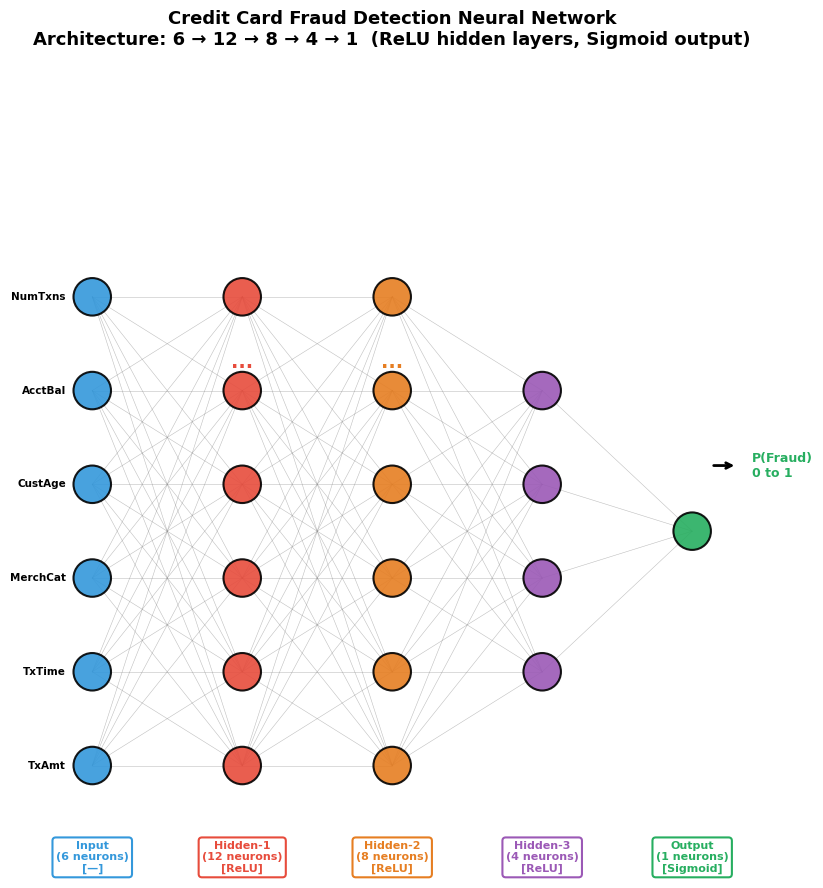

Compact diagram saved as: nn_architecture_compact.png


In [7]:
# ============================================================
# STEP 7: Detailed Architecture Diagram with Activation Labels
# ============================================================
# A cleaner, annotated version of the network showing:
# - Layer types and sizes
# - Activation functions
# - Data flow direction
# - Input feature names

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 10)
ax.set_ylim(-1, 10)
ax.axis('off')
ax.set_aspect('equal')

# Layer x-positions
layer_x = [1.0, 3.0, 5.0, 7.0, 9.0]   # X coordinates for each layer
activations = ['—', 'ReLU', 'ReLU', 'ReLU', 'Sigmoid']  # Activation per layer

# Compact representation (show max 6 neurons per layer, use ellipsis for more)
display_sizes = [6, 6, 6, 4, 1]  # Displayed neurons (capped at 6)
ellipsis_flag = [False, True, True, False, False]  # Show '...' if layer has more than displayed

r = 0.25   # Neuron radius

for l_idx in range(len(display_sizes)):
    n_show  = display_sizes[l_idx]   # How many circles to draw
    x_l     = layer_x[l_idx]
    color_l = layer_colors[l_idx]

    # Compute y positions (centered vertically in range [0.5, 8])
    y_spacing = 7.5 / max(display_sizes)
    y_top = 0.5 + (max(display_sizes) - n_show) * y_spacing / 2
    y_pos_list = [y_top + j * y_spacing for j in range(n_show)]

    # Draw connections to next layer
    if l_idx < len(display_sizes) - 1:
        n_next  = display_sizes[l_idx + 1]
        x_next  = layer_x[l_idx + 1]
        y_sp_n  = 7.5 / max(display_sizes)
        y_top_n = 0.5 + (max(display_sizes) - n_next) * y_sp_n / 2
        y_pos_next = [y_top_n + j * y_sp_n for j in range(n_next)]

        for y_c in y_pos_list:
            for y_n in y_pos_next:
                ax.plot([x_l, x_next], [y_c, y_n],
                        'gray', linewidth=0.4, alpha=0.5, zorder=1)

    # Draw neuron circles
    for j, y_p in enumerate(y_pos_list):
        circle = plt.Circle((x_l, y_p), r,
                             color=color_l, ec='black', lw=1.5, zorder=3, alpha=0.9)
        ax.add_patch(circle)

        # Label input neurons
        if l_idx == 0:
            short_labels = ['TxAmt', 'TxTime', 'MerchCat', 'CustAge', 'AcctBal', 'NumTxns']
            ax.text(x_l - r - 0.1, y_p, short_labels[j],
                    ha='right', va='center', fontsize=7.5, fontweight='bold')

    # Show '...' if layer was truncated
    if ellipsis_flag[l_idx]:
        ax.text(x_l, y_pos_list[-1] - y_spacing * 0.7, '...',
                ha='center', va='center', fontsize=14, fontweight='bold', color=color_l)

    # Layer label box (below each column)
    actual_count = layer_sizes[l_idx]
    act_name     = activations[l_idx]
    label_text   = f'{layer_labels[l_idx]}\n({actual_count} neurons)\n[{act_name}]'
    ax.text(x_l, -0.5, label_text, ha='center', va='top',
            fontsize=8, fontweight='bold', color=color_l,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color_l, lw=1.5))

# Output arrow
ax.annotate('', xy=(9.6, 4.5), xytext=(9.25, 4.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(9.8, 4.5, 'P(Fraud)\n0 to 1', ha='left', va='center',
        fontsize=9, fontweight='bold', color='#27ae60')

ax.set_title('Credit Card Fraud Detection Neural Network\n'
             'Architecture: 6 → 12 → 8 → 4 → 1  (ReLU hidden layers, Sigmoid output)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('nn_architecture_compact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Compact diagram saved as: nn_architecture_compact.png')

# STEP 8: Architecture Explanation & Design Justification

## Why This Architecture?

| Layer | Neurons | Activation | Purpose |
|-------|---------|------------|--------|
| Input | 6 | None | One neuron per feature |
| Hidden-1 | 12 | ReLU | Feature extraction — detect basic patterns |
| Hidden-2 | 8 | ReLU | Feature combination — detect complex combinations |
| Hidden-3 | 4 | ReLU | Feature compression — distill key signals |
| Output | 1 | Sigmoid | Binary probability: 0=Genuine, 1=Fraud |

## Why ReLU in Hidden Layers?
- **Solves the vanishing gradient problem** (gradients don't saturate for large positive values)
- **Computationally efficient**: just `max(0, x)`
- **Introduces non-linearity**: enables learning complex patterns
- Alternative: LeakyReLU for sparse activation issues

## Why Sigmoid in Output Layer?
- Outputs a **probability between 0 and 1** (ideal for binary classification)
- Combined with **Binary Cross-Entropy loss** during training
- Threshold at **0.5** → `P > 0.5 = Fraud`, `P ≤ 0.5 = Genuine`
- In fraud detection, you may lower threshold (e.g., 0.3) to **prioritize Recall** (catch more fraud)

## Training Process
1. **Forward Pass**: Input → through all layers → output probability
2. **Loss Calculation**: Binary Cross-Entropy = `-[y*log(ŷ) + (1-y)*log(1-ŷ)]`
3. **Backpropagation**: Compute gradient of loss w.r.t. each weight
4. **Weight Update**: `W = W - α × ∂L/∂W` (gradient descent, learning rate α)
5. **Repeat** for all batches and epochs until convergence